# Library

In [ ]:
# !jupyter nbextension enable --py widgetsnbextension

In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.optim.lr_scheduler import _LRScheduler
import torch.utils.data as data

import torchvision.transforms as transforms
import torchvision.datasets as datasets
from torchvision import models
from torch.utils.data import Dataset

from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix
from sklearn.metrics import ConfusionMatrixDisplay
from tqdm.notebook import tqdm, trange
import matplotlib.pyplot as plt
import numpy as np

import copy
import random
import time

c:\Users\Andrian Rakhmatsyah\AppData\Local\Programs\Python\Python310\lib\site-packages\transformers\utils\generic.py:441: UserWarning: torch.utils._pytree._register_pytree_node is deprecated. Please use torch.utils._pytree.register_pytree_node instead.
  _torch_pytree._register_pytree_node(


In [ ]:
import os
os.environ['CUDA_LAUNCH_BLOCKING'] = '1'
# os.environ['PYTORCH_CUDA_ALLOC_CONF'] = "expandable_segments:True"

In [ ]:
torch.cuda.current_device()

0

# Load Data

In [ ]:
train_data = datasets.ImageFolder(root=r'D:\experimen\ADR\dataset\Leukimia-split\train', transform=transforms.Compose([transforms.Resize([224, 224]), transforms.ToTensor()]))
valid_data = datasets.ImageFolder(root=r'D:\experimen\ADR\dataset\Leukimia-split\valid', transform=transforms.Compose([transforms.Resize([224, 224]), transforms.ToTensor()]))
test_data = datasets.ImageFolder(root=r'D:\experimen\ADR\dataset\Leukimia-split\test', transform=transforms.Compose([transforms.Resize([224, 224]), transforms.ToTensor()]))

In [ ]:
print(f'Number of training examples: {len(train_data)}')
print(f'Number of validation examples: {len(valid_data)}')
print(f'Number of testing examples: {len(test_data)}')

Number of training examples: 10341
Number of validation examples: 1293
Number of testing examples: 1294


In [ ]:
BATCH_SIZE = 128

train_iterator = data.DataLoader(train_data,
                                 shuffle=True,
                                 batch_size=BATCH_SIZE)

valid_iterator = data.DataLoader(valid_data,
                                 batch_size=BATCH_SIZE)

test_iterator = data.DataLoader(test_data,
                                 batch_size=BATCH_SIZE)

# Load Model

In [ ]:
import torch
import torch.nn.functional as F
from torch import nn
from einops import rearrange
from einops.layers.torch import Rearrange
import numpy as np


class SWVITEmbedding(nn.Module):
    def __init__(self, patch_size=4, emb_size=96):
        super().__init__()
        self.linear_embedding = nn.Conv2d(3, emb_size, kernel_size = patch_size, stride = patch_size)
        self.rearrange = Rearrange('b c h w -> b (h w) c')

    def forward(self, x):
        x = self.linear_embedding(x)
        x = self.rearrange(x)
        return x


class PatchMerging(nn.Module):
    def __init__(self, emb_size):
        super().__init__()
        self.linear = nn.Linear(4*emb_size, 2*emb_size)

    def forward(self, x):
        B, L, C = x.shape
        H = W = int(np.sqrt(L)/2)
        x = rearrange(x, 'b (h s1 w s2) c -> b (h w) (s1 s2 c)', s1=2, s2=2, h=H, w=W)
        x = self.linear(x)
        return x

class ShiftedWindowMSA(nn.Module):
    def __init__(self, emb_size, num_heads, window_size=7, shifted=True):
        super().__init__()
        self.emb_size = emb_size
        self.num_heads = num_heads
        self.window_size = window_size
        self.shifted = shifted
        self.linear1 = nn.Linear(emb_size, 3*emb_size)
        self.linear2 = nn.Linear(emb_size, emb_size)
        self.pos_embeddings = nn.Parameter(torch.randn(window_size*2 - 1, window_size*2 - 1))
        self.indices = torch.tensor(np.array([[x, y] for x in range(window_size) for y in range(window_size)]))
        self.relative_indices = self.indices[None, :, :] - self.indices[:, None, :]
        self.relative_indices += self.window_size - 1
    def forward(self, x):
        h_dim = self.emb_size / self.num_heads
        height = width = int(np.sqrt(x.shape[1]))
        x = self.linear1(x)

        x = rearrange(x, 'b (h w) (c k) -> b h w c k', h=height, w=width, k=3, c=self.emb_size)

        if self.shifted:
            x = torch.roll(x, (-self.window_size//2, -self.window_size//2), dims=(1,2))

        x = rearrange(x, 'b (Wh w1) (Ww w2) (e H) k -> b H Wh Ww (w1 w2) e k', w1 = self.window_size, w2 = self.window_size, H = self.num_heads)

        Q, K, V = x.chunk(3, dim=6)
        Q, K, V = Q.squeeze(-1), K.squeeze(-1), V.squeeze(-1)
        wei = (Q @ K.transpose(4,5)) / np.sqrt(h_dim)

        rel_pos_embedding = self.pos_embeddings[self.relative_indices[:, :, 0], self.relative_indices[:, :, 1]]
        wei += rel_pos_embedding

        if self.shifted:
            row_mask = torch.zeros((self.window_size**2, self.window_size**2)).to(device) # .cuda()
            row_mask[-self.window_size * (self.window_size//2):, 0:-self.window_size * (self.window_size//2)] = float('-inf')
            row_mask[0:-self.window_size * (self.window_size//2), -self.window_size * (self.window_size//2):] = float('-inf')
            column_mask = rearrange(row_mask, '(r w1) (c w2) -> (w1 r) (w2 c)', w1=self.window_size, w2=self.window_size)
            wei[:, :, -1, :] += row_mask
            wei[:, :, :, -1] += column_mask

        wei = F.softmax(wei, dim=-1) @ V

        x = rearrange(wei, 'b H Wh Ww (w1 w2) e -> b (Wh w1) (Ww w2) (H e)', w1 = self.window_size, w2 = self.window_size, H = self.num_heads)
        x = rearrange(x, 'b h w c -> b (h w) c')

        return self.linear2(x)

class MLP(nn.Module):
    def __init__(self, emb_size):
        super().__init__()
        self.ff = nn.Sequential(
                         nn.Linear(emb_size, 4*emb_size),
                         nn.GELU(),
                         nn.Linear(4*emb_size, emb_size),
                  )

    def forward(self, x):
        return self.ff(x)

class SWVITEncoder(nn.Module):
    def __init__(self, emb_size, num_heads, window_size=7):
        super().__init__()
        self.WMSA = ShiftedWindowMSA(emb_size, num_heads, window_size, shifted=False)
        self.SWMSA = ShiftedWindowMSA(emb_size, num_heads, window_size, shifted=True)
        self.ln = nn.LayerNorm(emb_size)
        self.MLP = MLP(emb_size)

    def forward(self, x):
        # Window Attention
        x = x + self.WMSA(self.ln(x))
        x = x + self.MLP(self.ln(x))
        # shifted Window Attention
        x = x + self.SWMSA(self.ln(x))
        x = x + self.MLP(self.ln(x))

        return x

class SW_ViT(nn.Module):
    def __init__(self, num_class, emb_size = 96):
        super().__init__()
        self.Embedding = SWVITEmbedding()
        self.PatchMerging = nn.ModuleList()
        # emb_size = 96
        # num_class = 100
        for i in range(3):
            self.PatchMerging.append(PatchMerging(emb_size))
            emb_size *= 2

        self.stage1 = SWVITEncoder(96, 3)
        self.stage2 = SWVITEncoder(192, 6)
        self.stage3 = nn.ModuleList([SWVITEncoder(384, 12),
                                     SWVITEncoder(384, 12),
                                     SWVITEncoder(384, 12)
                                    ])
        self.stage4 = SWVITEncoder(768, 24)

        self.avgpool1d = nn.AdaptiveAvgPool1d(output_size = 1)
        self.avg_pool_layer = nn.AvgPool1d(kernel_size=49)

        self.layer = nn.Linear(768, num_class)

    def forward(self, x):
        x = self.Embedding(x)
        x = self.stage1(x)
        x = self.PatchMerging[0](x)
        x = self.stage2(x)
        x = self.PatchMerging[1](x)
        for stage in self.stage3:
            x = stage(x)
        x = self.PatchMerging[2](x)
        x = self.stage4(x)
        x = self.layer(self.avgpool1d(x.transpose(1, 2)).squeeze(2))
        return x

In [ ]:
classes = train_data.classes
CLASS_NUM = len(classes)

model = SW_ViT(CLASS_NUM)

In [ ]:
classes

['ALL', 'AML', 'CLL', 'CML']

# Training

In [ ]:
START_LR = 0.001 # 1e-3

optimizer = optim.Adam(model.parameters(), lr=START_LR)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

criterion = nn.CrossEntropyLoss()

model = model.to(device)
criterion = criterion.to(device)

In [ ]:
def calculate_accuracy(y_pred, y):
    top_pred = y_pred.argmax(1, keepdim=True)
    correct = top_pred.eq(y.view_as(top_pred)).sum()
    acc = correct.float() / y.shape[0]
    return acc

In [ ]:
def train(model, iterator, optimizer, criterion, device):

    epoch_loss = 0
    epoch_acc = 0

    model.train()

    for (x, y) in tqdm(iterator, desc="Training", leave=False):

        x = x.to(device)
        y = y.to(device)

        optimizer.zero_grad()

        y_pred = model(x)

        loss = criterion(y_pred, y)

        acc = calculate_accuracy(y_pred, y)

        loss.backward()

        optimizer.step()

        epoch_loss += loss.item()
        epoch_acc += acc.item()

    return epoch_loss / len(iterator), epoch_acc / len(iterator)

In [ ]:
def evaluate(model, iterator, criterion, device):

    epoch_loss = 0
    epoch_acc = 0

    model.eval()

    with torch.no_grad():

        for (x, y) in tqdm(iterator, desc="Evaluating", leave=False):

            x = x.to(device)
            y = y.to(device)

            y_pred = model(x)

            loss = criterion(y_pred, y)

            acc = calculate_accuracy(y_pred, y)

            epoch_loss += loss.item()
            epoch_acc += acc.item()

    return epoch_loss / len(iterator), epoch_acc / len(iterator)

In [ ]:
def epoch_time(start_time, end_time):
    elapsed_time = end_time - start_time
    elapsed_mins = int(elapsed_time / 60)
    elapsed_secs = int(elapsed_time - (elapsed_mins * 60))
    return elapsed_mins, elapsed_secs

In [ ]:
torch.cuda.empty_cache()

In [ ]:
EPOCHS = 50
train_loss_list, valid_loss_list, train_acc_list, valid_acc_list = [], [], [], []
best_valid_loss = float('inf')

for epoch in trange(EPOCHS, desc="Epochs"):

    start_time = time.monotonic()

    train_loss, train_acc = train(model, train_iterator, optimizer, criterion, device)
    valid_loss, valid_acc = evaluate(model, valid_iterator, criterion, device)

    train_loss_list.append(train_loss)
    valid_loss_list.append(valid_loss)
    train_acc_list.append(train_acc)
    valid_acc_list.append(valid_acc)

    if valid_loss < best_valid_loss:
        best_valid_loss = valid_loss
        torch.save(model, 'swvit_pretrain (2).pt')

    end_time = time.monotonic()

    epoch_mins, epoch_secs = epoch_time(start_time, end_time)

    print(f'Epoch: {epoch+1:02} | Epoch Time: {epoch_mins}m {epoch_secs}s')
    print(f'\tTrain Loss: {train_loss:.3f} | Train Acc: {train_acc*100:.2f}%')
    print(f'\t Val. Loss: {valid_loss:.3f} |  Val. Acc: {valid_acc*100:.2f}%')

    # if (epoch + 1) % 100 == 0:
    #     torch.save(model, f'swvit_pretrain_{epoch + 1}.pt')

Epochs:   0%|          | 0/50 [00:00<?, ?it/s]

Training:   0%|          | 0/81 [00:00<?, ?it/s]

Evaluating:   0%|          | 0/11 [00:00<?, ?it/s]

Epoch: 01 | Epoch Time: 24m 36s
	Train Loss: 7.544 | Train Acc: 33.82%
	 Val. Loss: 1.106 |  Val. Acc: 52.17%


Training:   0%|          | 0/81 [00:00<?, ?it/s]

...

Evaluating:   0%|          | 0/11 [00:00<?, ?it/s]

Epoch: 49 | Epoch Time: 17m 38s
	Train Loss: 0.539 | Train Acc: 80.09%
	 Val. Loss: 0.757 |  Val. Acc: 76.29%


Training:   0%|          | 0/81 [00:00<?, ?it/s]

Evaluating:   0%|          | 0/11 [00:00<?, ?it/s]

Epoch: 50 | Epoch Time: 17m 37s
	Train Loss: 0.394 | Train Acc: 85.12%
	 Val. Loss: 0.401 |  Val. Acc: 85.71%


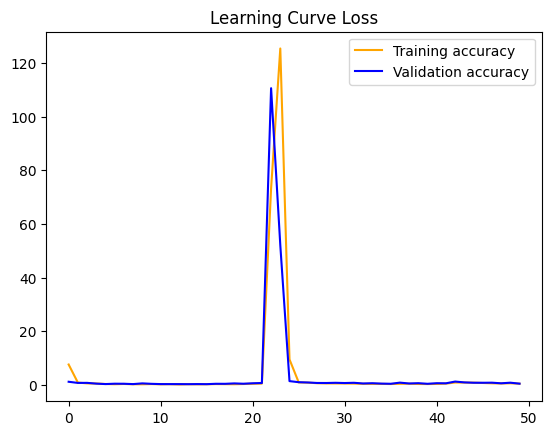

In [ ]:
epochs = range(len(valid_acc_list))

plt.plot(sharey=True, figsize=(10, 10))
plt.plot(epochs, train_loss_list, 'orange', label='Training accuracy')
plt.plot(epochs, valid_loss_list, 'b', label='Validation accuracy')
plt.title('Learning Curve Loss')
plt.legend()
plt.show()


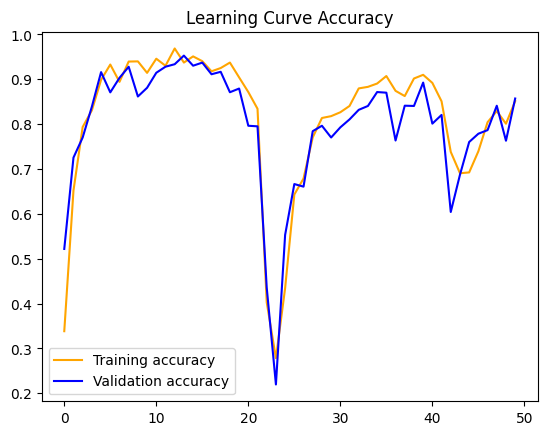

In [ ]:

plt.plot(sharey=True, figsize=(10, 10))
plt.plot(epochs, train_acc_list, 'orange', label='Training accuracy')
plt.plot(epochs, valid_acc_list, 'b', label='Validation accuracy')
plt.title('Learning Curve Accuracy')
plt.legend()
plt.show()


plt.show()

# Evaluation

In [ ]:
model = torch.load('swvit_pretrain (2).pt')
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
criterion = nn.CrossEntropyLoss()

In [ ]:
def evaluate(model, iterator, criterion, device):

    epoch_loss = 0
    epoch_acc = 0

    model.eval()

    with torch.no_grad():

        for (x, y) in tqdm(iterator, desc="Evaluating", leave=False):

            x = x.to(device)
            y = y.to(device)

            y_pred = model(x)

            loss = criterion(y_pred, y)

            acc = calculate_accuracy(y_pred, y)

            epoch_loss += loss.item()
            epoch_acc += acc.item()

    return epoch_loss / len(iterator), epoch_acc / len(iterator)

In [ ]:
test_loss, test_acc = evaluate(model, test_iterator, criterion, device)

print(f'Test Loss: {test_loss:.3f} | Test Acc: {test_acc*100:.2f}%')

Evaluating:   0%|          | 0/11 [00:00<?, ?it/s]

Test Loss: 0.204 | Test Acc: 93.77%


In [ ]:
def get_predictions(model, iterator, device):

    model.eval()

    images = []
    labels = []
    probs = []

    with torch.no_grad():

        for (x, y) in iterator:

            x = x.to(device)

            y_pred = model(x)

            y_prob = F.softmax(y_pred, dim=-1)

            images.append(x.cpu())
            labels.append(y.cpu())
            probs.append(y_prob.cpu())

    images = torch.cat(images, dim=0)
    labels = torch.cat(labels, dim=0)
    probs = torch.cat(probs, dim=0)

    return images, labels, probs

In [ ]:
images, labels, probs = get_predictions(model, test_iterator, device)

In [ ]:
pred_labels = torch.argmax(probs, 1)

In [ ]:
print(classification_report(labels, pred_labels))

              precision    recall  f1-score   support

           0       0.97      0.97      0.97       298
           1       0.95      0.96      0.96       366
           2       0.96      0.94      0.95       305
           3       0.98      0.98      0.98       325

    accuracy                           0.96      1294
   macro avg       0.96      0.96      0.96      1294
weighted avg       0.96      0.96      0.96      1294



In [ ]:
def plot_confusion_matrix(labels, pred_labels, classes):

    fig = plt.figure(figsize=(10, 10))
    ax = fig.add_subplot(1, 1, 1)
    cm = confusion_matrix(labels, pred_labels)
    cm = ConfusionMatrixDisplay(cm, display_labels=classes)
    cm.plot(values_format='d', cmap='Blues', ax=ax)
    plt.xticks(rotation=20)

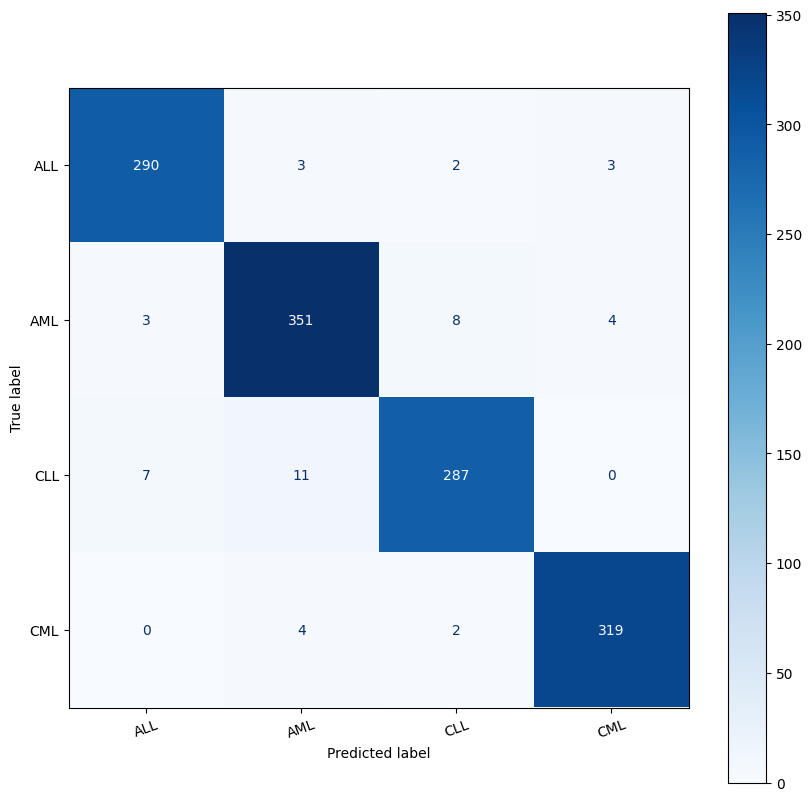

In [ ]:
plot_confusion_matrix(labels, pred_labels, classes)